In [40]:
# importing the data 

import numpy as np
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

X_train = pd.read_csv('../data/processed/X_train_preprocessed.csv')
X_test = pd.read_csv('../data/processed/X_test_preprocessed.csv')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [42]:
# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVR
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , classification_report , auc , roc_auc_score,confusion_matrix
import xgboost as xgb
# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Utilities
import joblib
import json
import os

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("CSAT Score Prediction - Model Training Pipeline")
print("=" * 50)
print(f"Started at: {datetime.now()}")

CSAT Score Prediction - Model Training Pipeline
Started at: 2025-09-03 01:10:19.133778


In [43]:
X_train.shape , X_test.shape, y_train.shape, y_test.shape

((68725, 21), (17182, 21), (68725,), (17182,))

issues : nan in city_category , product dummies and shift dummies not included ..

In [44]:
columns_to_scale = ['remark_char_length','remark_word_count','remark_sentence_count','sentiment_polarity','sentiment_subjectivity','time_to_issueHrs','IssueResponseTimeHrs','category_fe' ,'category_encoded' ,'sub_category_fe' ,'subcat_te' ,'item_price_log']

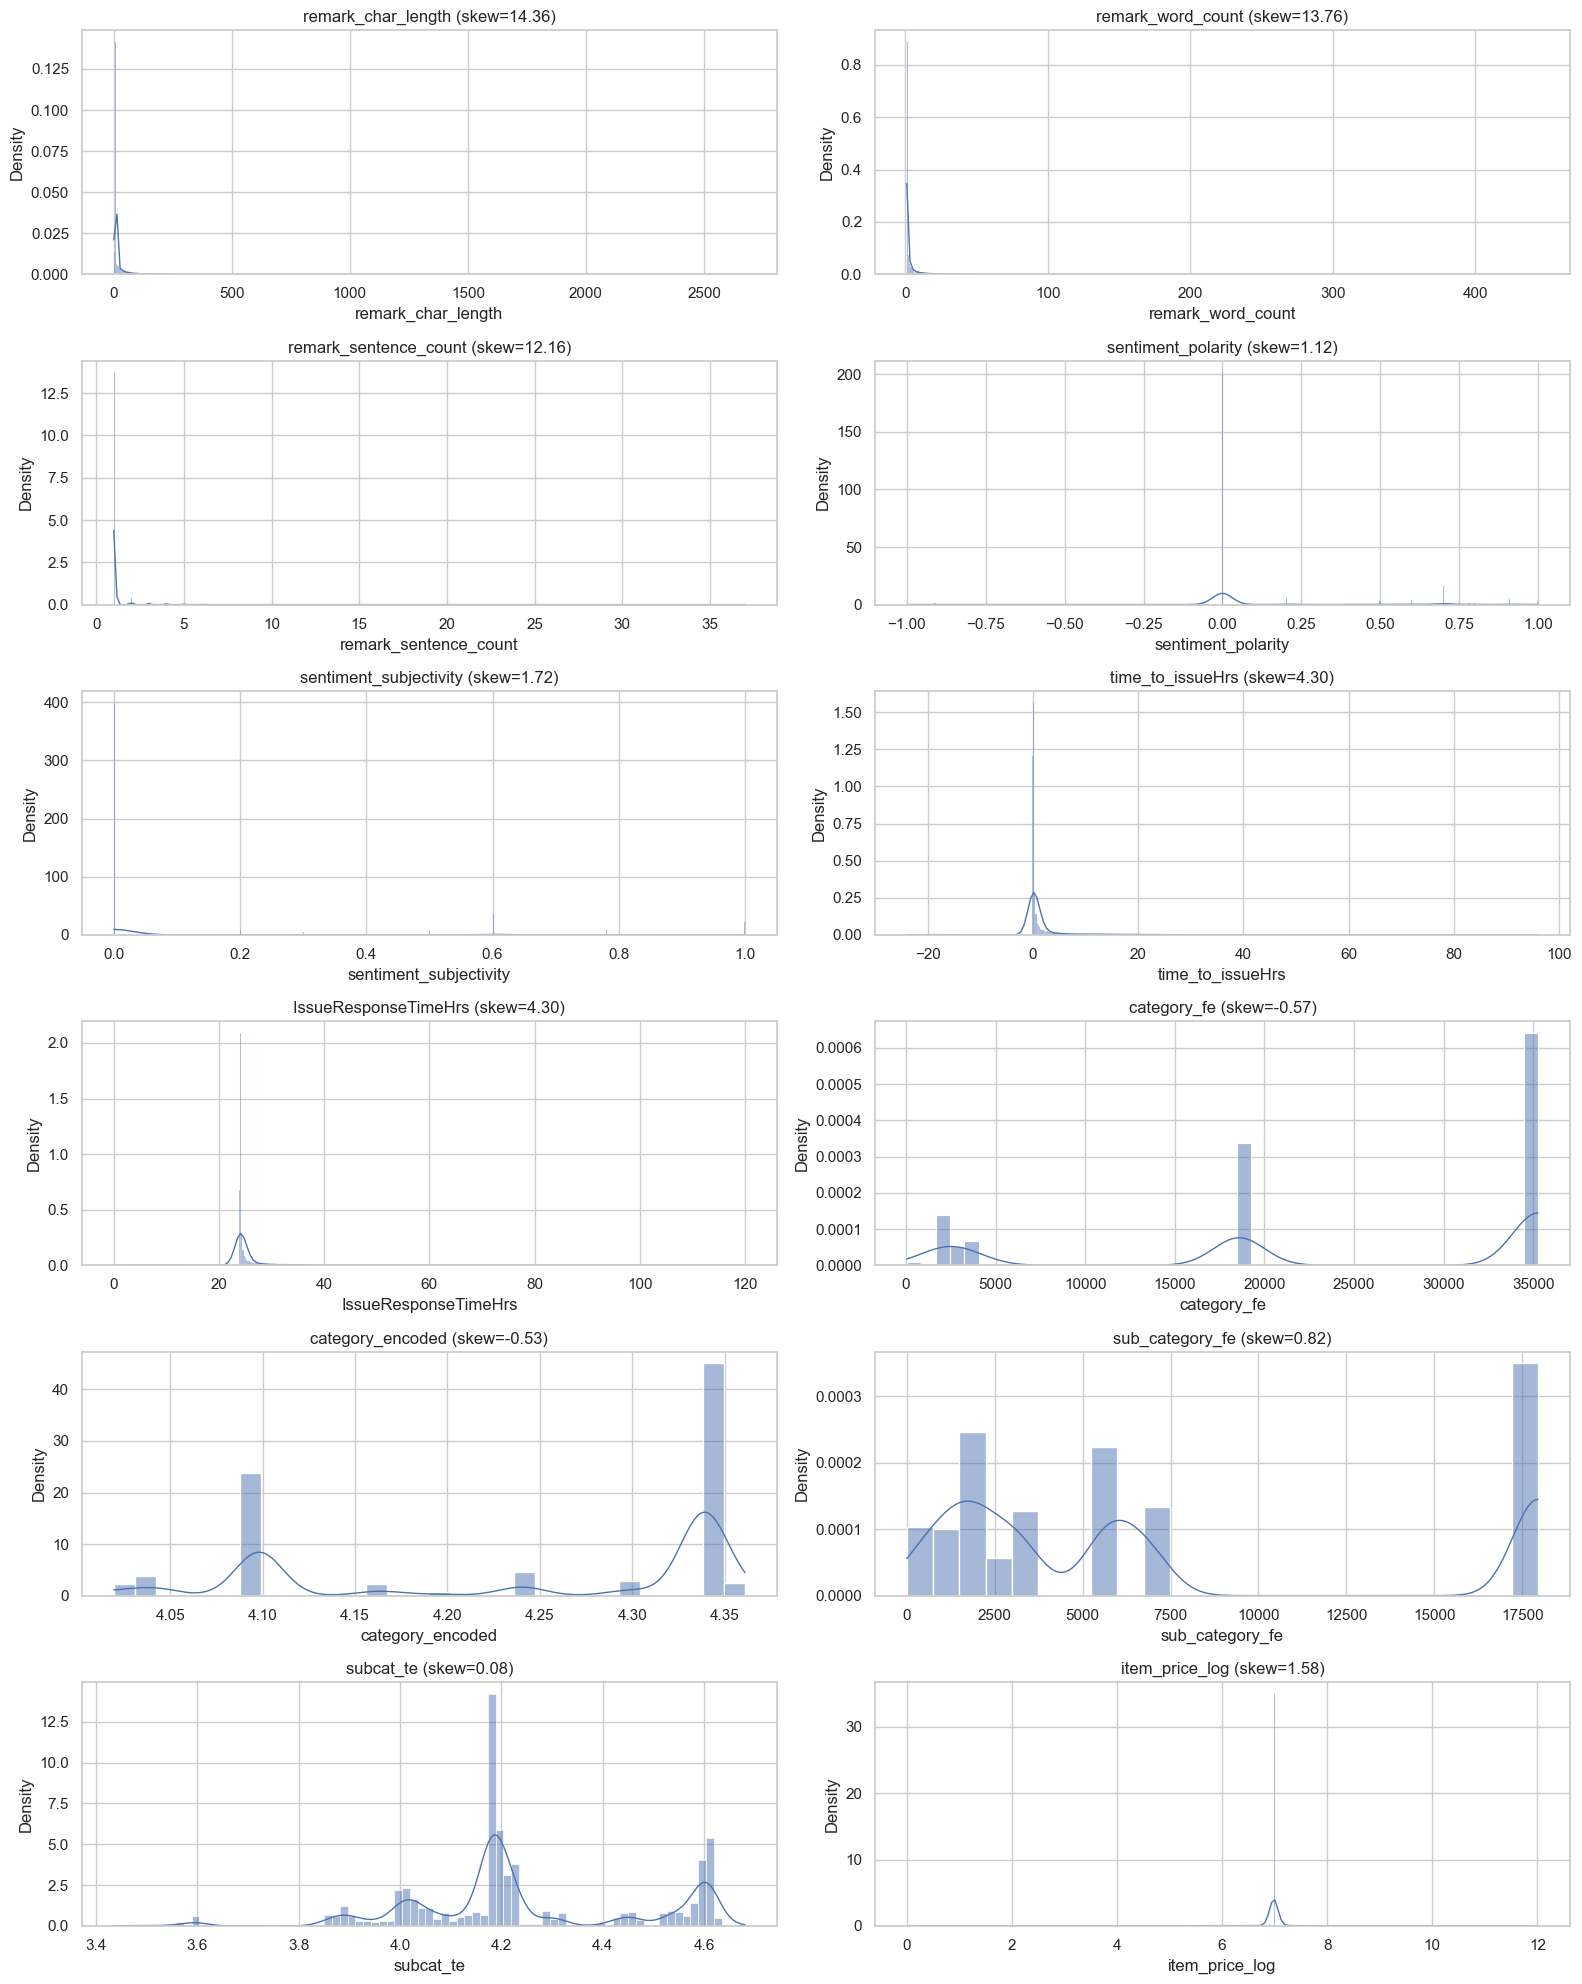

In [45]:
# 1. Plot raw distributions & compute skew
plt.figure(figsize=(16, 20))
for i, col in enumerate(columns_to_scale, 1):
    plt.subplot(6, 2, i)
    sns.histplot(X_train[col].dropna(), kde=True, stat='density', line_kws={'linewidth':1})
    skew_val = X_train[col].dropna().skew()
    plt.title(f"{col} (skew={skew_val:.2f})")
plt.tight_layout()
plt.show()

In [46]:
# 2. Decide which need transformation: skew > |1| is highly skewed
to_transform = [col for col in columns_to_scale if abs(X_train[col].dropna().skew()) > 1.0]
print("Highly skewed features:", to_transform)

# 3. Apply Yeo-Johnson to the skewed ones (handles zeros & negatives)
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_trans = X_train.copy()
X_train_trans[to_transform] = pt.fit_transform(X_train[to_transform])

Highly skewed features: ['remark_char_length', 'remark_word_count', 'remark_sentence_count', 'sentiment_polarity', 'sentiment_subjectivity', 'time_to_issueHrs', 'IssueResponseTimeHrs', 'item_price_log']


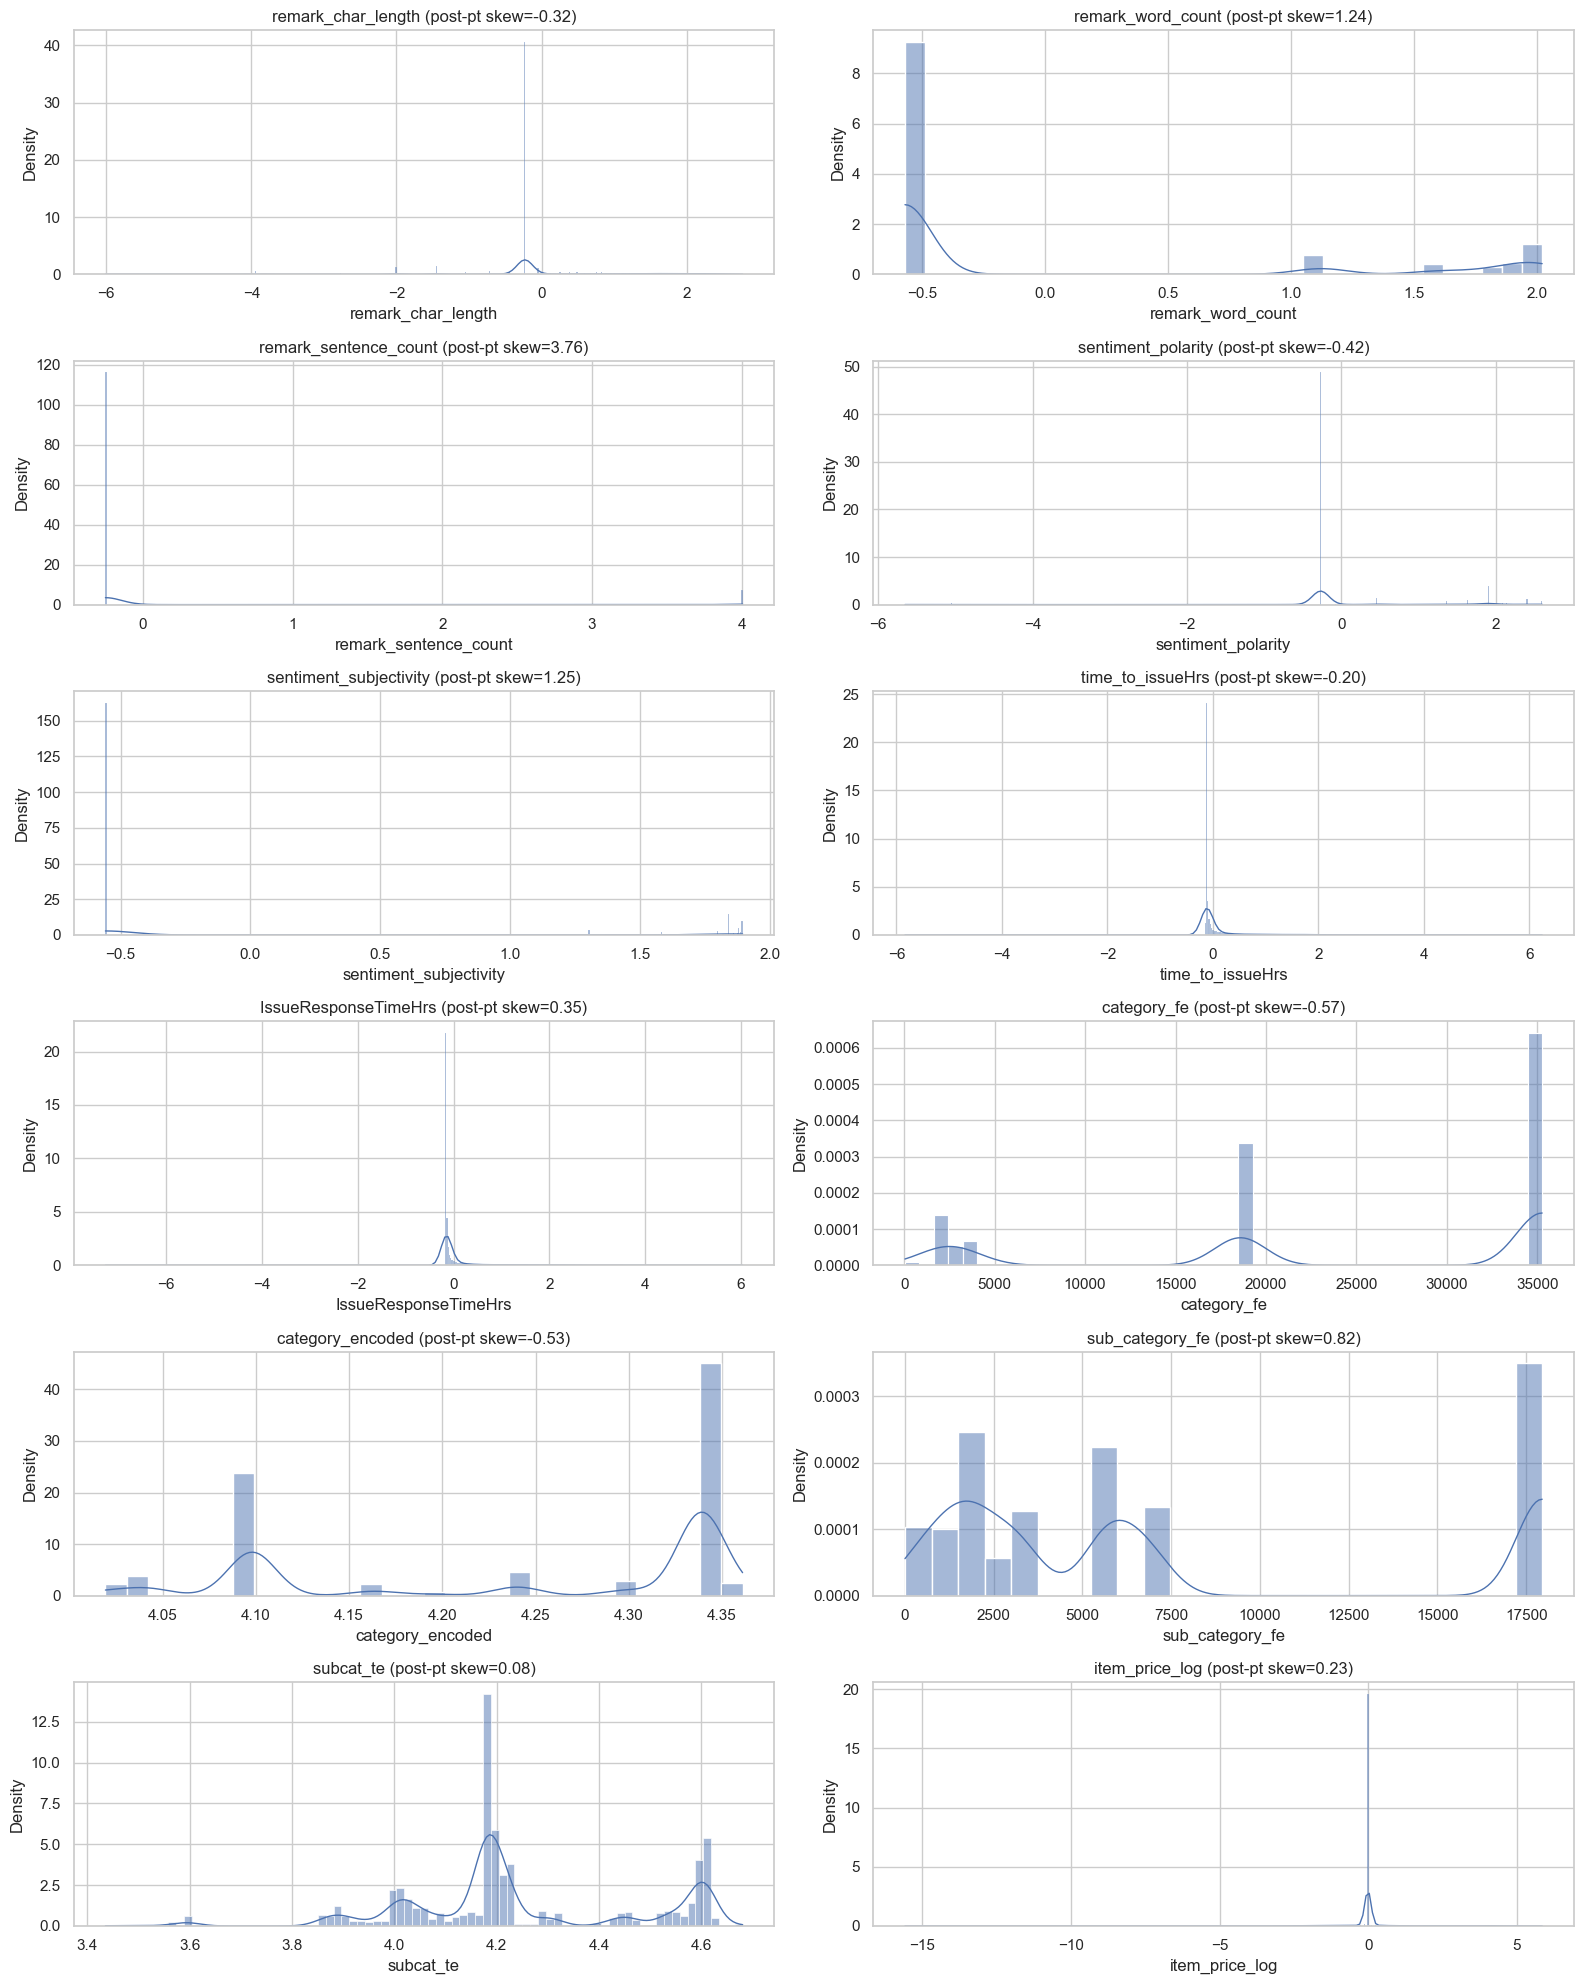

In [47]:
# 4. Plot post-transform distributions
plt.figure(figsize=(16, 20))
for i, col in enumerate(columns_to_scale, 1):
    plt.subplot(6, 2, i)
    sns.histplot(X_train_trans[col].dropna(), kde=True, stat='density', line_kws={'linewidth':1})
    skew_val = X_train_trans[col].dropna().skew()
    plt.title(f"{col} (post-pt skew={skew_val:.2f})")
plt.tight_layout()
plt.show()

In [48]:
to_transform

['remark_char_length',
 'remark_word_count',
 'remark_sentence_count',
 'sentiment_polarity',
 'sentiment_subjectivity',
 'time_to_issueHrs',
 'IssueResponseTimeHrs',
 'item_price_log']

In [49]:
# X_test_trans
X_test_trans = X_test.copy()
X_test_trans[to_transform] = pt.transform(X_test[to_transform])

In [50]:
# save the list of transformed columns as json
with open("../artifacts/preprocess/features_to_transform.json", "w") as f:
    json.dump(to_transform, f)
# save the powertrasformer object pt using joblib
joblib.dump(pt, "../artifacts/preprocess/power_transformer.joblib")

['../artifacts/preprocess/power_transformer.joblib']

In [51]:
print(columns_to_scale)
print(to_transform)
to_scale = [col for col in columns_to_scale if col not in to_transform]
print(to_scale)

['remark_char_length', 'remark_word_count', 'remark_sentence_count', 'sentiment_polarity', 'sentiment_subjectivity', 'time_to_issueHrs', 'IssueResponseTimeHrs', 'category_fe', 'category_encoded', 'sub_category_fe', 'subcat_te', 'item_price_log']
['remark_char_length', 'remark_word_count', 'remark_sentence_count', 'sentiment_polarity', 'sentiment_subjectivity', 'time_to_issueHrs', 'IssueResponseTimeHrs', 'item_price_log']
['category_fe', 'category_encoded', 'sub_category_fe', 'subcat_te']


In [52]:

scaler = StandardScaler()
# scaling only the to_scale columns
X_train_trans_scaled = X_train_trans.copy()
X_test_trans_scaled = X_test_trans.copy()
X_train_trans_scaled[to_scale] = scaler.fit_transform(X_train_trans_scaled[to_scale])
X_test_trans_scaled[to_scale] = scaler.transform(X_test_trans_scaled[to_scale])

# save the scaler
joblib.dump(scaler, "../artifacts/preprocess/scaler.joblib")
# save the final data
# save transformed datasets
X_train_trans_scaled.to_csv("../data/processed/X_train_transformed.csv", index=False)
X_test_trans_scaled.to_csv("../data/processed/X_test_transformed.csv", index=False)


Checking the data drift using evidently ..

In [53]:
# Auto-detecting version and importing correctly
try:
    # Try new API first
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    print("✅ Using Evidently v0.7+ (New API)")
    
except ImportError:
    try:
        # Fall back to legacy API
        from evidently.legacy.report import Report
        from evidently.legacy.metric_preset import DataDriftPreset
        print("✅ Using Evidently v0.6 (Legacy API)")
        
    except ImportError:
        print("❌ Evidently not installed. Run: pip install evidently")
# Create and run drift report
drift_report = Report(metrics=[DataDriftPreset()])
drift_report.run(reference_data=X_train_trans_scaled, current_data=X_test_trans_scaled)

# Save interactive HTML report
drift_report.save_html("drift_report.html")


✅ Using Evidently v0.6 (Legacy API)


Checked the data drift report : Shows no data drift in any of the features

Thereby proceeding to model training.

Model Training

In [54]:
y_test.shape

(17182,)

In [55]:
# creating validation split
X_val, X_test, y_val, y_test = train_test_split(X_test_trans_scaled, y_test, test_size=0.5, random_state=42)


In [56]:
X_val.shape , X_test.shape

((8591, 21), (8591, 21))

In [57]:
X_train.shape , X_val.shape , X_test.shape

((68725, 21), (8591, 21), (8591, 21))

In [58]:
y_train.shape , y_val.shape , y_test.shape

((68725,), (8591,), (8591,))

In [59]:

os.makedirs("../data/processed/train_val_test", exist_ok=True)
X_train_trans_scaled.to_csv("../data/processed/train_val_test/X_train.csv", index=False)
X_val.to_csv("../data/processed/train_val_test/X_val.csv", index=False)
X_test.to_csv("../data/processed/train_val_test/X_test.csv", index=False)
# saving y_train , y_val , y_test
np.save("../data/processed/train_val_test/y_train.npy", y_train)
np.save("../data/processed/train_val_test/y_val.npy", y_val)
np.save("../data/processed/train_val_test/y_test.npy", y_test)


In [60]:
# Metric Evaluation function for classification models


# import all classification metrics 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# creating the evaluate function which takes X_train , y_train , X_val , y_val and then evaluate all these metrics 

def evaluate(model, X_train, y_train, X_val, y_val):
    # Checking the training accuracy
    train_accuracy = model.score(X_train, y_train)
    print(f"Training accuracy: {train_accuracy}")
    # Checking the validation accuracy
    val_accuracy = model.score(X_val, y_val)
    print(f"Validation accuracy: {val_accuracy}")

    # Getting predictions
    ypred_train = model.predict(X_train)
    ypred_val = model.predict(X_val)

    # Precision, Recall, F1-Score
    print("Training precision:", precision_score(y_train, ypred_train, average='weighted'))
    print("Validation precision:", precision_score(y_val, ypred_val, average='weighted'))
    print("Training recall:", recall_score(y_train, ypred_train, average='weighted'))
    print("Validation recall:", recall_score(y_val, ypred_val, average='weighted'))
    print("Training F1-score:", f1_score(y_train, ypred_train, average='weighted'))
    print("Validation F1-score:", f1_score(y_val, ypred_val, average='weighted'))

    # Confusion matrix
    print("Training confusion matrix:")
    print(confusion_matrix(y_train, ypred_train))
    print("Validation confusion matrix:")
    print(confusion_matrix(y_val, ypred_val))

    # Classification report
    print("Training classification report:")
    print(classification_report(y_train, ypred_train))
    print("Validation classification report:")
    print(classification_report(y_val, ypred_val))


In [61]:
from sklearn.ensemble import RandomForestClassifier


# Use RandomForestClassifier instead
rf_classifier = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Built-in handling for imbalance
)

rf_classifier.fit(X_train, y_train)
evaluate(rf_classifier, X_train, y_train, X_val, y_val)

Training accuracy: 0.5241033102946526
Validation accuracy: 0.28425096030729835
Training precision: 0.7198479094005377
Validation precision: 0.6075803770468579
Training recall: 0.5241033102946526
Validation recall: 0.28425096030729835
Training F1-score: 0.573118667226546
Validation F1-score: 0.28750828834175535
Training confusion matrix:
[[ 5132   779   765  1390   923]
 [   20   809    27   154    46]
 [  116   119  1294   325   201]
 [  868   781   804  4571  1918]
 [ 4313  3436  3787 11934 24213]]
Validation confusion matrix:
[[1058    0    0    0   80]
 [ 115    0    0    0    8]
 [ 211    0    0    0   32]
 [ 984    1    0    0  133]
 [4582    3    0    0 1384]]
Training classification report:
              precision    recall  f1-score   support

           1       0.49      0.57      0.53      8989
           2       0.14      0.77      0.23      1056
           3       0.19      0.63      0.30      2055
           4       0.25      0.51      0.33      8942
           5       0.8

validation confustion matrix shows that in validation set , the model is able to predict good enough for csat score 1 only . for all other classes it shows high prediction error. Even for class 5 which had highest number of samples in training and testing.

In [63]:
# Logistic regression
lr = LogisticRegression(multi_class='multinomial', solver='saga', class_weight='balanced')
lr.fit(X_train, y_train)
evaluate(lr, X_train, y_train, X_val, y_val)

Training accuracy: 0.13241178610403784
Validation accuracy: 0.25840996391572574
Training precision: 0.4750779735103991
Validation precision: 0.5704380674597207
Training recall: 0.13241178610403784
Validation recall: 0.25840996391572574
Training F1-score: 0.058283881022204345
Validation F1-score: 0.2582629527058309
Training confusion matrix:
[[ 2423  1153     1  5412     0]
 [  271    93     0   692     0]
 [  454   172     0  1429     0]
 [ 1663   697     0  6579     3]
 [ 8404  3641     1 35632     5]]
Validation confusion matrix:
[[ 596   36    8  409   89]
 [  40    5    1   60   17]
 [  83    8    1  105   46]
 [ 222   34    8  680  174]
 [1308  301   83 3339  938]]
Training classification report:
              precision    recall  f1-score   support

           1       0.18      0.27      0.22      8989
           2       0.02      0.09      0.03      1056
           3       0.00      0.00      0.00      2055
           4       0.13      0.74      0.22      8942
           5      

In [21]:
y_train_zero = y_train - 1
y_val_zero   = y_val   - 1
y_test_zero  = y_test  - 1

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb



# Random forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',  # multiclass softmax
    num_class=5,                  # or num_class=3 for tri-class 
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train_zero)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [36]:
print("Logistic Regression:")
evaluate(lr, X_train, y_train, X_val, y_val)
print("Random Forest:")
evaluate(rf, X_train, y_train, X_val, y_val)
print("XGBoost:")
evaluate(xgb_clf, X_train, y_train_zero, X_val, y_val_zero)


Logistic Regression:
Training accuracy: 0.3758275736631502
Validation accuracy: 0.3735176427791924
Training precision: 0.6493252318087062
Validation precision: 0.6484815027055414
Training recall: 0.3758275736631502
Validation recall: 0.3735176427791924
Training F1-score: 0.44457100194744165
Validation F1-score: 0.44375513946421324
Training confusion matrix:
[[ 3304   928   826  1540   635]
 [  208   142   129   258   115]
 [  331   200   291   512   297]
 [  793   733  1090  2643  1879]
 [ 3619  2990  4522 12712 14283]]
Validation confusion matrix:
[[ 762  239  230  380  145]
 [  45   31   32   72   24]
 [  73   62   70  142   77]
 [ 195  175  282  665  487]
 [ 905  737 1181 3128 3606]]
Training classification report:
              precision    recall  f1-score   support

           1       0.40      0.46      0.43      7233
           2       0.03      0.17      0.05       852
           3       0.04      0.18      0.07      1631
           4       0.15      0.37      0.21      7138
 

In [37]:
# for balanced class training , implementing smote to create X_train_smote and X_test_smote 

# import smote
from imblearn.over_sampling import SMOTE

# Create SMOTE instance
smote = SMOTE(random_state=42)

# Fit and resample the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote.shape , y_train_smote.shape


((190630, 21), (190630,))

In [41]:
# implementing smote tomek as well 
# import smote tomek
from imblearn.combine import SMOTETomek

# Create SMOTE-Tomek instance
smote_tomek = SMOTETomek(random_state=42)

# Fit and resample the training data
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train)
X_train_smote_tomek.shape , y_train_smote_tomek.shape

((175226, 21), (175226,))

In [ ]:
# Implementing models to these now 

rf_classifier_smote = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Built-in handling for imbalance
)

rf_classifier_smote.fit(X_train_smote, y_train_smote)
# evaluate(rf_classifier_smote, X_train_smote, y_train_smote, X_val, y_val)


rf_classifier_smote_tomek = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Built-in handling for imbalance
)

rf_classifier_smote_tomek.fit(X_train_smote_tomek, y_train_smote_tomek)
# evaluate(rf_classifier_smote_tomek, X_train_smote_tomek, y_train_smote_tomek, X_val, y_val)

lr_smote = LogisticRegression(multi_class='multinomial', solver='saga', class_weight='balanced')
lr_smote.fit(X_train_smote, y_train_smote)
# evaluate(lr_smote, X_train_smote, y_train_smote, X_val, y_val)

lr_smote_tomek = LogisticRegression(multi_class='multinomial', solver='saga', class_weight='balanced')
lr_smote_tomek.fit(X_train_smote_tomek, y_train_smote_tomek)
# evaluate(lr_smote_tomek, X_train_smote_tomek, y_train_smote_tomek, X_val, y_val)



xgb_clf_smote = xgb.XGBClassifier(
    objective='multi:softprob',  # multiclass softmax
    num_class=5,                  # or num_class=3 for tri-class
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_clf_smote.fit(X_train_smote, y_train_smote - 1)

# evaluate
# evaluate(xgb_clf_smote, X_train_smote, y_train_smote-1, X_val, y_val-1)

xgb_clf_smote_tomek = xgb.XGBClassifier(
    objective='multi:softprob',  # multiclass softmax
    num_class=5,                  # or num_class=3 for tri-class
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_clf_smote_tomek.fit(X_train_smote_tomek, y_train_smote_tomek - 1)
# evaluate
# evaluate(xgb_clf_smote_tomek, X_train_smote_tomek, y_train_smote_tomek-1, X_val, y_val-1)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [43]:
print("Random Forest with SMOTE:")
evaluate(rf_classifier_smote, X_train_smote, y_train_smote, X_val, y_val)
print("Random Forest with SMOTE + Tomek:")
evaluate(rf_classifier_smote_tomek, X_train_smote_tomek, y_train_smote_tomek, X_val, y_val)
print("Logistic Regression with SMOTE:")
evaluate(lr_smote, X_train_smote, y_train_smote, X_val, y_val)
print("Logistic Regression with SMOTE + Tomek:")
evaluate(lr_smote_tomek, X_train_smote_tomek, y_train_smote_tomek, X_val, y_val)
print("XGBoost with SMOTE:")
evaluate(xgb_clf_smote, X_train_smote, y_train_smote-1, X_val, y_val-1)
print("XGBoost with SMOTE + Tomek:")
evaluate(xgb_clf_smote_tomek, X_train_smote_tomek, y_train_smote_tomek-1, X_val, y_val-1)

Random Forest with SMOTE:
Training accuracy: 0.6378796621727955
Validation accuracy: 0.5262277191706075
Training precision: 0.6440311869208637
Validation precision: 0.6193456656520889
Training recall: 0.6378796621727955
Validation recall: 0.5262277191706075
Training F1-score: 0.6328502650427611
Validation F1-score: 0.5657860600876756
Training confusion matrix:
[[21208  5629  4335  3837  3117]
 [  748 31518  2760  2115   985]
 [ 1185  6462 25568  2663  2248]
 [ 2590  5637  4788 17385  7726]
 [ 2458  3289  2350  4109 25920]]
Validation confusion matrix:
[[ 818  218  144  137  439]
 [  59   28   23   22   72]
 [  88   69   45   56  166]
 [ 210  212  144  264  974]
 [ 935  827  563 1154 6078]]
Training classification report:
              precision    recall  f1-score   support

           1       0.75      0.56      0.64     38126
           2       0.60      0.83      0.70     38126
           3       0.64      0.67      0.66     38126
           4       0.58      0.46      0.51     3812